# 07. Belgilar yaratish (Feature Engineering)

Maqsad — har bir guruh (OTM × yo'nalish × til × shakl) uchun o'tish balini bashorat qilishga tayyor jadval:

1. To'liq nomzodlar to'plami: har bir abituriyent → bozor va ball
2. Bozor bo'yicha raqobat belgilari
3. Guruhning bozor ichidagi o'rni
4. Nisbiy maqsad: o'tish balidan yuqori ball olgan nomzodlar ulushi
5. Tekshirish va `data/processed/model_data.csv` ga saqlash

**Leakage qoidasi:** faqat tanlovdan oldin ma'lum bo'lgan narsalar belgi bo'ladi — kvotalar, guruh xususiyatlari, bozordagi nomzodlar soni va ballari. Nomzodlarning qaysi OTM/yo'nalishni tanlagani faqat abituriyentni bozorga biriktirish uchun ishlatiladi (bu uning o'z imtihon fanlariga teng) va keyin tashlab yuboriladi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

In [2]:
otm = pd.read_csv('../data/processed/otm_prepared.csv')
bozorlar = pd.read_csv('../data/processed/bozorlar.csv')
abt = pd.read_csv('../data/raw/abiturents.csv', usecols=['ID', 'yonalishi', 'toplagan_bali'])

print('otm:     ', otm.shape)
print('bozorlar:', bozorlar.shape)
print('abt:     ', abt.shape)

otm:      (5547, 17)
bozorlar: (38, 2)
abt:      (1787836, 3)


## 1. To'liq nomzodlar to'plami

`abts_prepared.csv` da 12 860 abituriyent yo'q (`01`-notebookda fanlari topilmagan). Shuning uchun nomzodlarni to'g'ridan-to'g'ri `abiturents.csv` dan olamiz: har bir tanlovning yo'nalish nomi → fanlar juftligi → bozor. Abituriyentning bali hamma tanlovlarida bir xil (`06`-notebookda tekshirilgan).

In [3]:
def bosh_joy(s):
    return s.str.replace(r'\s+', ' ', regex=True).str.strip()

nom_bozor = (otm.assign(nom=bosh_joy(otm['yunalish_nomi']))
                .drop_duplicates('nom').set_index('nom')['bozor'])
abt['bozor'] = bosh_joy(abt['yonalishi']).map(nom_bozor)

assert (abt.groupby('ID')['toplagan_bali'].nunique() == 1).all(), 'ball tanlovga qarab farq qiladi'

nomzodlar = (abt.dropna(subset=['bozor'])
                .drop_duplicates('ID')[['ID', 'bozor', 'toplagan_bali']]
                .reset_index(drop=True))
assert nomzodlar['ID'].is_unique

print(f"Abituriyentlar: {abt['ID'].nunique():,}")
print(f"Bozorga biriktirilgan: {len(nomzodlar):,}")
print(f"Bozorsiz qolgan: {abt['ID'].nunique() - len(nomzodlar):,}")

Abituriyentlar: 357,561
Bozorga biriktirilgan: 357,561
Bozorsiz qolgan: 0


In [4]:
nomzodlar.to_csv('../data/processed/nomzodlar.csv', index=False, encoding='utf-8')
print('Saqlandi: data/processed/nomzodlar.csv')
nomzodlar['bozor'].value_counts()

Saqlandi: data/processed/nomzodlar.csv


bozor
Matematika + Chet tili                               57892
Matematika + Fizika                                  57133
Biologiya + Kimyo                                    47559
Ingliz tili + Ona tili va adabiyoti                  33411
Biologiya + Ona tili va adabiyoti                    30179
Ona tili va adabiyoti + Chet tili                    25023
Kasbiy (ijodiy imtihon) + Kasbiy (ijodiy imtihon)    22016
Huquqshunoslik fanlari + Chet tili                   16096
Tarix + Chet tili                                    14923
Ona tili va adabiyoti + Matematika                   13497
Kimyo + Biologiya                                     9949
Tarix + Ona tili va adabiyoti                         8619
Tarix + Geografiya                                    5957
Rus tili va adabiyoti + Chet tili                     3816
Matematika + Ona tili va adabiyoti                    2575
Rus tili va adabiyoti + Tarix                         2392
Rus tili + Ona tili va adabiyoti                  

## 2. Bozor bo'yicha raqobat belgilari

- `bozor_nomzodlar` — bozordagi nomzodlar soni
- `bozor_q50` … `bozor_q95` — ballar kvantillari, `bozor_189_soni` — 189 va undan yuqori ball olganlar
- `bozor_grant_kvota`, `bozor_shartnoma_kvota` — bozordagi jami o'rinlar
- `bozor_nomzod_orin` — bitta o'ringa (grant + shartnoma) nechta nomzod
- `bozor_grant_chegara` — o'rinlar eng yaxshilardan boshlab to'ldirilsa, oxirgi grant o'riniga kirgan nomzodning bali (bozordagi N-o'rindagi ball, N = bozordagi grant kvotasi)
- `bozor_shartnoma_chegara` — xuddi shunday, N = grant + shartnoma kvotasi. Nomzodlar o'rinlardan kam bo'lsa — eng past ball.

In [5]:
# Har bir bozor uchun ballar kamayish tartibida
bozor_ballar = {b: np.sort(g.to_numpy())[::-1]
                for b, g in nomzodlar.groupby('bozor')['toplagan_bali']}

def n_orindagi_ball(bozor, n):
    ballar = bozor_ballar[bozor]
    if n <= 0:
        return np.nan
    return ballar[min(int(n), len(ballar)) - 1]

q = nomzodlar.groupby('bozor')['toplagan_bali']
bozor_df = pd.DataFrame({
    'bozor_nomzodlar': q.size(),
    'bozor_q50': q.quantile(0.50),
    'bozor_q75': q.quantile(0.75),
    'bozor_q90': q.quantile(0.90),
    'bozor_q95': q.quantile(0.95),
    'bozor_189_soni': q.apply(lambda s: (s >= 189).sum()),
})
kvota = otm.groupby('bozor')[['grant_kvota_soni', 'shartnoma_kvota_soni']].sum()
bozor_df['bozor_grant_kvota'] = kvota['grant_kvota_soni']
bozor_df['bozor_shartnoma_kvota'] = kvota['shartnoma_kvota_soni']
bozor_df['bozor_guruhlar'] = otm.groupby('bozor').size()
bozor_df['bozor_nomzod_orin'] = (bozor_df['bozor_nomzodlar']
                                 / (bozor_df['bozor_grant_kvota'] + bozor_df['bozor_shartnoma_kvota']))
bozor_df['bozor_grant_chegara'] = [n_orindagi_ball(b, k) for b, k in bozor_df['bozor_grant_kvota'].items()]
bozor_df['bozor_shartnoma_chegara'] = [
    n_orindagi_ball(b, g + s)
    for b, g, s in zip(bozor_df.index, bozor_df['bozor_grant_kvota'], bozor_df['bozor_shartnoma_kvota'])]

assert bozor_df.index.isin(otm['bozor']).all() and otm['bozor'].isin(bozor_df.index).all()
bozor_df.round(2).sort_values('bozor_nomzodlar', ascending=False)

,bozor_nomzodlar,bozor_q50,bozor_q75,bozor_q90,bozor_q95,bozor_189_soni,bozor_grant_kvota,bozor_shartnoma_kvota,bozor_guruhlar,bozor_nomzod_orin,bozor_grant_chegara,bozor_shartnoma_chegara
bozor,,,,,,,,,,,,
Matematika + Chet tili,57892,102.30,142.10,168.90,178.60,1289,1286,31438,749,1.77,189.0,95.9
Matematika + Fizika,57133,70.10,113.40,150.00,163.54,239,10731,38015,1535,1.17,127.4,59.0
Biologiya + Kimyo,47559,104.10,157.10,180.10,187.00,1613,5436,13153,819,2.56,178.1,131.5
Ingliz tili + Ona tili va adabiyoti,33411,169.80,180.60,186.40,188.90,1653,2448,12438,341,2.24,187.7,172.6
Biologiya + Ona tili va adabiyoti,30179,68.70,91.80,108.70,126.71,0,1141,15060,235,1.86,137.6,67.3
Ona tili va adabiyoti + Chet tili,25023,142.20,154.80,166.70,175.00,62,941,4226,84,4.84,177.7,157.3
Kasbiy (ijodiy imtihon) + Kasbiy (ijodiy imtihon),22016,116.70,142.50,164.80,170.30,5,2597,11478,763,1.56,162.6,104.3
Huquqshunoslik fanlari + Chet tili,16096,113.40,143.40,162.00,170.40,17,242,3664,62,4.12,178.6,144.3
Tarix + Chet tili,14923,140.30,169.00,186.80,189.00,1028,688,3667,96,3.43,189.0,165.7


## 3. Guruhning bozor ichidagi o'rni

- `jami_kvota` — guruhdagi grant + shartnoma o'rinlari
- `grant_kvota_ulushi`, `shartnoma_kvota_ulushi` — guruh kvotasining bozordagi jami kvotaga nisbati
- `asosiy_yunalish_guruhlar` — shu asosiy yo'nalish bozorda nechta guruhda o'qitiladi (taklif hajmi)

In [6]:
df = otm.merge(bozor_df, left_on='bozor', right_index=True, how='left', validate='many_to_one')

df['jami_kvota'] = df['grant_kvota_soni'] + df['shartnoma_kvota_soni']
df['grant_kvota_ulushi'] = df['grant_kvota_soni'] / df['bozor_grant_kvota']
df['shartnoma_kvota_ulushi'] = df['shartnoma_kvota_soni'] / df['bozor_shartnoma_kvota']
df['asosiy_yunalish_guruhlar'] = df.groupby(['bozor', 'asosiy_yunalish'])['otm_nomi'].transform('size')

df[['jami_kvota', 'grant_kvota_ulushi', 'shartnoma_kvota_ulushi', 'asosiy_yunalish_guruhlar']].describe().round(4)

,jami_kvota,grant_kvota_ulushi,shartnoma_kvota_ulushi,asosiy_yunalish_guruhlar
count,5547.0000,5547.0000,5547.0000,5547.0000
mean,33.3335,0.0058,0.0058,64.7548
std,43.2567,0.0406,0.0352,65.2741
min,1.0000,0.0000,0.0000,1.0000
25%,8.0000,0.0000,0.0003,19.0000
50%,25.0000,0.0004,0.0009,46.0000
75%,50.0000,0.0017,0.0026,84.0000
max,948.0000,1.0000,1.0000,259.0000


## 4. Nisbiy maqsad

`grant_ulush` — bozordagi nomzodlarning qancha qismi `grant_bali` dan yuqori yoki teng ball olgan (`shartnoma_ulush` — xuddi shunday). Keyingi yil model ulushni bashorat qiladi, uni yangi yilning ballar taqsimotiga qo'yib, ballga qaytaramiz (`ulushdan_ballga`).

Avval tekshiramiz: o'tish bali bozordagi eng yuqori balldan katta bo'lgan guruh bo'lmasligi kerak.

In [7]:
bozor_max = nomzodlar.groupby('bozor')['toplagan_bali'].max()
for tur in ['grant', 'shartnoma']:
    yuqori = (df[f'{tur}_bali'] > df['bozor'].map(bozor_max)).sum()
    print(f"{tur}: bozordagi eng yuqori balldan katta o'tish bali — {yuqori} ta guruh")

grant: bozordagi eng yuqori balldan katta o'tish bali — 0 ta guruh
shartnoma: bozordagi eng yuqori balldan katta o'tish bali — 0 ta guruh


In [8]:
def balldan_ulushga(bozor, ball):
    """Bozordagi nomzodlarning qancha qismi `ball` dan yuqori yoki teng."""
    if pd.isna(ball):
        return np.nan
    ballar = bozor_ballar[bozor]  # kamayish tartibida
    return np.searchsorted(-ballar, -ball, side='right') / len(ballar)

def ulushdan_ballga(bozor, ulush):
    """Teskari o'girish: eng yaxshi `ulush` qismining eng past bali."""
    if pd.isna(ulush):
        return np.nan
    ballar = bozor_ballar[bozor]
    k = min(max(int(round(ulush * len(ballar))), 1), len(ballar))
    return ballar[k - 1]

for tur in ['grant', 'shartnoma']:
    df[f'{tur}_ulush'] = [balldan_ulushga(b, x) for b, x in zip(df['bozor'], df[f'{tur}_bali'])]

df[['grant_ulush', 'shartnoma_ulush']].describe().round(4)

,grant_ulush,shartnoma_ulush
count,3376.0000,4718.0000
mean,0.2245,0.7049
std,0.1938,0.2784
min,0.0001,0.0154
25%,0.0646,0.4884
50%,0.1513,0.7910
75%,0.3585,0.9566
max,0.9996,1.0000


In [9]:
# Teskari o'girish qanchalik aniq? (ulush -> ball -> asl ball bilan solishtirish)
for tur in ['grant', 'shartnoma']:
    m = df[f'{tur}_bali'].notna()
    qaytgan = np.array([ulushdan_ballga(b, u) for b, u in zip(df.loc[m, 'bozor'], df.loc[m, f'{tur}_ulush'])])
    xato = np.abs(qaytgan - df.loc[m, f'{tur}_bali'].to_numpy())
    print(f"{tur}: MAE = {xato.mean():.3f} ball, max = {xato.max():.1f}, 1 balldan katta xato: {(xato > 1).sum()} ta")

grant: MAE = 0.000 ball, max = 0.0, 1 balldan katta xato: 0 ta
shartnoma: MAE = 0.000 ball, max = 0.0, 1 balldan katta xato: 0 ta


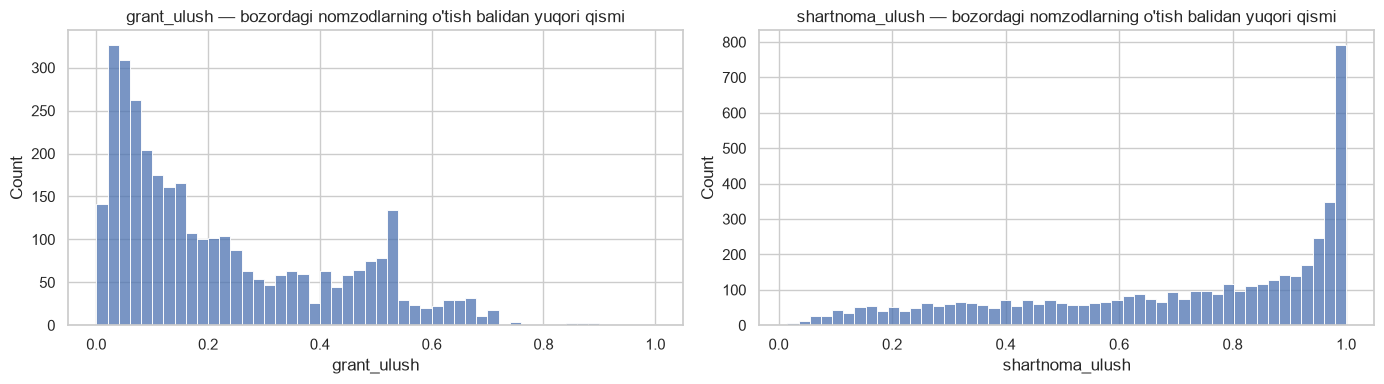

shartnoma_ulush >= 0.99 (deyarli hamma o'tadi): 539


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, tur in zip(axes, ['grant', 'shartnoma']):
    sns.histplot(df[f'{tur}_ulush'].dropna(), bins=50, ax=ax)
    ax.set_title(f'{tur}_ulush — bozordagi nomzodlarning o\'tish balidan yuqori qismi')
plt.tight_layout()
plt.show()

print('shartnoma_ulush >= 0.99 (deyarli hamma o\'tadi):', (df['shartnoma_ulush'] >= 0.99).sum())

## 5. Belgilar va maqsad o'rtasidagi bog'liqlik

Spearman korrelyatsiyasi — sonli belgilarning maqsad bilan monoton bog'liqligi (faqat dastlabki tekshiruv, model tanlovi emas).

In [11]:
sonli = ['grant_kvota_soni', 'shartnoma_kvota_soni', 'jami_kvota', 'grant_kvota_ulushi',
         'shartnoma_kvota_ulushi', 'asosiy_yunalish_guruhlar', 'bozor_nomzodlar', 'bozor_q50',
         'bozor_q90', 'bozor_nomzod_orin', 'bozor_grant_chegara', 'bozor_shartnoma_chegara']
maqsadlar = ['grant_bali', 'grant_ulush', 'shartnoma_bali', 'shartnoma_ulush']
df[sonli + maqsadlar].corr(method='spearman').loc[sonli, maqsadlar].round(2)

,grant_bali,grant_ulush,shartnoma_bali,shartnoma_ulush
grant_kvota_soni,-0.18,0.11,0.07,-0.10
shartnoma_kvota_soni,-0.01,-0.13,0.09,-0.10
jami_kvota,-0.04,-0.09,0.09,-0.12
grant_kvota_ulushi,-0.01,-0.09,0.16,-0.17
shartnoma_kvota_ulushi,-0.00,-0.12,0.25,-0.19
asosiy_yunalish_guruhlar,0.36,-0.29,-0.00,-0.07
bozor_nomzodlar,-0.08,0.10,-0.18,0.09
bozor_q50,0.58,-0.21,0.62,-0.34
bozor_q90,0.67,-0.19,0.53,-0.31
bozor_nomzod_orin,0.59,-0.34,0.52,-0.40


In [12]:
# Kategorial belgilar bo'yicha maqsadning tarqoqligi
kategorial = ['talim_shakli', 'talim_tili', 'hudud', 'tuman_kvotasi']
for col in kategorial:
    print(df.groupby(col)[['grant_ulush', 'shartnoma_ulush']].median().round(3), end='\n\n')

              grant_ulush  shartnoma_ulush
talim_shakli                              
Dual                  NaN            1.000
Kechki              0.640            0.835
Kunduzgi            0.151            0.746
Masofaviy           0.175            0.884

            grant_ulush  shartnoma_ulush
talim_tili                              
O'zbekcha         0.153            0.815
Qirg'iz           0.348            0.989
Qoraqalpoq        0.162            0.822
Qozoq             0.462            0.883
Tadjik            0.133            0.838
Turkman           0.625            1.000
Русский           0.131            0.645

                               grant_ulush  shartnoma_ulush
hudud                                                      
Andijon viloyati                     0.109            0.802
Buxoro viloyati                      0.139            0.802
Farg‘ona viloyati                    0.145            0.851
Jizzax viloyati                      0.219            0.934
Namangan vi

## 6. Saqlash

In [13]:
BELGILAR = ['hudud', 'otm_nomi', 'asosiy_yunalish', 'talim_tili', 'talim_shakli', 'tuman_kvotasi',
            'fanlar_juftligi', 'bozor'] + sonli + [
            'bozor_q75', 'bozor_q95', 'bozor_189_soni', 'bozor_grant_kvota', 'bozor_shartnoma_kvota',
            'bozor_guruhlar']
MAQSADLAR = ['grant_bali', 'shartnoma_bali', 'grant_ulush', 'shartnoma_ulush']

model_data = df[['yunalish_nomi'] + BELGILAR + MAQSADLAR]

assert len(model_data) == len(otm)
assert model_data[BELGILAR].notna().all().drop(['bozor_grant_chegara']).all()
for tur in ['grant', 'shartnoma']:
    assert model_data[f'{tur}_ulush'].isna().equals(model_data[f'{tur}_bali'].isna())
    assert model_data[f'{tur}_ulush'].dropna().between(0, 1).all()

model_data.to_csv('../data/processed/model_data.csv', index=False, encoding='utf-8')
print('Saqlandi: data/processed/model_data.csv', model_data.shape)
print('Belgilar:', len(BELGILAR))

Saqlandi: data/processed/model_data.csv (5547, 31)
Belgilar: 26


## Xulosa

**Natija:** `model_data.csv` — 5 547 guruh, 26 belgi, 4 maqsad (`grant_bali`, `shartnoma_bali`, `grant_ulush`, `shartnoma_ulush`). Qo'shimcha: `nomzodlar.csv` — 357 561 abituriyent, har biri bitta bozorda.

- **Nomzodlar to'liq:** `abiturents.csv` orqali barcha 357 561 abituriyent bozorga biriktirildi (`abts_prepared.csv` da 344 701 edi). Endi hech bir guruhning o'tish bali o'z bozoridagi eng yuqori balldan katta emas — avvalgi 4 ta mantiqsiz holat yo'qoldi.
- **Nisbiy maqsad teskari o'giriladi xatosiz:** ulush → ball → asl ball, MAE = 0.000. Ya'ni ulushni bashorat qilish ballni bashorat qilish bilan bir xil ma'lumotni saqlaydi.
- **Eng kuchli belgilar — bozor darajasidagi raqobat:** `bozor_grant_chegara` (grant bali bilan Spearman 0.71), `bozor_q90` (0.67), `bozor_nomzod_orin` (0.59). Shartnoma uchun `bozor_shartnoma_chegara` (0.64) va `bozor_q50` (0.62).
- Guruh darajasidagi kvota belgilari xom ball bilan kuchsiz bog'liq (|ρ| ≤ 0.25) — bir bozor ichidagi farqni asosan OTM, yo'nalish, til va shakl tushuntirishi kerak.
- **Shartnoma ulushida shift effekti:** 539 guruhda `shartnoma_ulush` ≥ 0.99 — o'tish bali minimal 56.7 ga yaqin, ya'ni bozordagi deyarli hamma o'ta oladi. Modelda buni hisobga olish kerak (masalan, logit o'zgartirish).
- Tuman kvotalari faqat grant uchun (shartnoma kvotasi yo'q). Kechki/Masofaviy/Dual shakllarda grant deyarli yo'q, shartnoma ulushi yuqori — raqobat past.

### Keyingi qadam (`08_modeling`)
1. Baseline: bozor × asosiy yo'nalish bo'yicha median.
2. Gradient boosting — xom ball va nisbiy ulush uchun alohida, grant va shartnoma uchun alohida (4 model).
3. OTM bo'yicha GroupKFold, MAE ballarda (ulush modeli bashoratlari `ulushdan_ballga` bilan ballga qaytariladi).